# Comprehensive Evaluation: NER Model vs SOMEF for CodeMeta Extraction

This evaluation compares the performance of our NER model against SOMEF for extracting CodeMeta fields from software repositories.

**Evaluated Fields:**
- citation, relatedLink, referencePublication, buildInstructions
- softwareRequirements, runtimePlatform, operatingSystem, license
- continuousIntegration, and additional fields discovered by SOMEF

In [1]:
import json
import logging
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
from collections import defaultdict, Counter
from typing import Dict, List, Set, Any, Tuple

logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')
logger = logging.getLogger(__name__)

plt.style.use('default')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

In [ ]:
class Evaluator:
    def __init__(self, data_dir: str, output_dir: str):
        self.data_dir = Path(data_dir)
        self.output_dir = Path(output_dir)
        self.output_dir.mkdir(exist_ok=True)
        
        # Expected fields and their mappings
        self.expected_fields = {
            'citation', 'relatedLink', 'referencePublication', 'buildInstructions',
            'softwareRequirements', 'runtimePlatform', 'operatingSystem', 'license',
            'continuousIntegration', 'url', 'identifier', 'codeRepository', 'author',
            'description', 'keywords', 'downloadUrl', 'issueTracker', 'logo'
        }
        
        # SOMEF field mappings
        self.field_mappings = {
            'relatedLink': 'url'
        }
    
    def normalize_license(self, license_data: Any) -> Set[str]:
        """Extract license information from different formats."""
        licenses = set()
        
        if isinstance(license_data, list):
            for item in license_data:
                if isinstance(item, dict):
                    if 'name' in item:
                        licenses.add(item['name'])
                    if 'spdx_id' in item:
                        licenses.add(item['spdx_id'])
                    if 'url' in item:
                        licenses.add(item['url'])
                elif isinstance(item, str):
                    licenses.add(item)
        elif isinstance(license_data, dict):
            if 'name' in license_data:
                licenses.add(license_data['name'])
            if 'spdx_id' in license_data:
                licenses.add(license_data['spdx_id'])
            if 'url' in license_data:
                licenses.add(license_data['url'])
        elif isinstance(license_data, str):
            licenses.add(license_data)
        
        return licenses
    
    def extract_urls(self, data: Any) -> Set[str]:
        """Extract URLs from various formats."""
        urls = set()
        
        if isinstance(data, list):
            for item in data:
                if isinstance(item, str):
                    urls.add(item)
                elif isinstance(item, dict) and 'url' in item:
                    urls.add(item['url'])
        elif isinstance(data, str):
            urls.add(data)
        elif isinstance(data, dict) and 'url' in data:
            urls.add(data['url'])
        
        return urls
    
    def extract_field_entities(self, data: Dict, field: str) -> Set[str]:
        """Extract entities from a specific field."""
        value = data.get(field)
        if not value:
            return set()
        
        # Special handling for license
        if field == 'license':
            return self.normalize_license(value)
        
        # Special handling for URL fields
        if field in ['buildInstructions', 'continuousIntegration', 'relatedLink', 'url']:
            return self.extract_urls(value)
        
        # General extraction
        entities = set()
        
        if isinstance(value, list):
            for item in value:
                if isinstance(item, dict):
                    if 'name' in item:
                        entities.add(item['name'])
                    elif 'text' in item:
                        entities.add(item['text'])
                    elif 'bibliographicCitation' in item:
                        entities.add(item['bibliographicCitation'])
                elif isinstance(item, str):
                    entities.add(item)
        elif isinstance(value, dict):
            if 'name' in value:
                entities.add(value['name'])
            elif 'text' in value:
                entities.add(value['text'])
        elif isinstance(value, str):
            entities.add(value)
        
        return entities
    
    def get_all_fields_in_data(self, data: Dict) -> Set[str]:
        """Get all fields present in the data."""
        return set(data.keys()) - {'@context', '@type', 'name'}
    
    def calculate_metrics(self, gt: Set, pred: Set) -> Dict[str, float]:
        """Calculate precision, recall, F1."""
        if not gt and not pred:
            return {'precision': 1.0, 'recall': 1.0, 'f1': 1.0}
        if not pred:
            return {'precision': 0.0, 'recall': 0.0, 'f1': 0.0}
        if not gt:
            return {'precision': 0.0, 'recall': 0.0, 'f1': 0.0}
        
        intersection = gt.intersection(pred)
        precision = len(intersection) / len(pred)
        recall = len(intersection) / len(gt)
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        
        return {'precision': precision, 'recall': recall, 'f1': f1}
    
    def load_and_evaluate(self) -> Dict[str, Any]:
        """Load data and perform evaluation."""
        projects = {}
        
        # Load all projects
        for gt_file in self.data_dir.glob('*_groundtruth_codemeta.json'):
            project_name = gt_file.stem.replace('_groundtruth_codemeta', '')
            
            model_patterns = [f"{project_name.lower()}_model_codemeta.json", f"{project_name}_model_codemeta.json"]
            somef_patterns = [f"{project_name.lower()}_somef_codemeta.json", f"{project_name}_somef_codemeta.json"]
            
            model_file = somef_file = None
            
            for pattern in model_patterns:
                if (self.data_dir / pattern).exists():
                    model_file = self.data_dir / pattern
                    break
            
            for pattern in somef_patterns:
                if (self.data_dir / pattern).exists():
                    somef_file = self.data_dir / pattern
                    break
            
            if model_file and somef_file:
                try:
                    with open(gt_file) as f:
                        gt_data = json.load(f)
                    with open(model_file) as f:
                        model_data = json.load(f)
                    with open(somef_file) as f:
                        somef_data = json.load(f)
                    
                    projects[project_name] = {
                        'ground_truth': gt_data,
                        'model': model_data,
                        'somef': somef_data
                    }
                except Exception as e:
                    logger.warning(f"Failed to load {project_name}: {e}")
        
        # Collect all fields across all data sources
        all_fields = set()
        for project_data in projects.values():
            all_fields.update(self.get_all_fields_in_data(project_data['ground_truth']))
            all_fields.update(self.get_all_fields_in_data(project_data['model']))
            all_fields.update(self.get_all_fields_in_data(project_data['somef']))
        
        # Map SOMEF fields to ground truth fields
        for field in list(all_fields):
            if field in self.field_mappings:
                all_fields.add(self.field_mappings[field])
        
        logger.info(f"Evaluating {len(projects)} projects across {len(all_fields)} fields")
        logger.info(f"Fields found: {sorted(all_fields)}")
        
        # Perform evaluation
        results = {
            'projects': list(projects.keys()),
            'all_fields': sorted(all_fields),
            'project_metrics': {},
            'field_metrics': {},
            'entity_extraction': {},
            'coverage_matrix': {'projects': [], 'gt_fields': [], 'model_fields': [], 'somef_fields': []}
        }
        
        for project_name, data in projects.items():
            gt_data = data['ground_truth']
            model_data = data['model']
            somef_data = data['somef']
            
            project_results = {
                'model_metrics': {'precision': [], 'recall': [], 'f1': []},
                'somef_metrics': {'precision': [], 'recall': [], 'f1': []},
                'field_presence': {'gt': [], 'model': [], 'somef': []},
                'entities_extracted': {'gt': {}, 'model': {}, 'somef': {}}
            }
            
            for field in all_fields:
                # Handle field mapping for SOMEF
                somef_field = field
                if field == 'url':
                    # Check both 'url' and 'relatedLink' in SOMEF
                    somef_entities = set()
                    somef_entities.update(self.extract_field_entities(somef_data, 'url'))
                    somef_entities.update(self.extract_field_entities(somef_data, 'relatedLink'))
                else:
                    somef_entities = self.extract_field_entities(somef_data, somef_field)
                
                gt_entities = self.extract_field_entities(gt_data, field)
                model_entities = self.extract_field_entities(model_data, field)
                
                # Store entity extraction results
                project_results['entities_extracted']['gt'][field] = list(gt_entities)
                project_results['entities_extracted']['model'][field] = list(model_entities)
                project_results['entities_extracted']['somef'][field] = list(somef_entities)
                
                # Track field presence
                project_results['field_presence']['gt'].append(1 if gt_entities else 0)
                project_results['field_presence']['model'].append(1 if model_entities else 0)
                project_results['field_presence']['somef'].append(1 if somef_entities else 0)
                
                # Calculate metrics only if ground truth has entities for this field
                if gt_entities:
                    model_metrics = self.calculate_metrics(gt_entities, model_entities)
                    somef_metrics = self.calculate_metrics(gt_entities, somef_entities)
                    
                    project_results['model_metrics']['precision'].append(model_metrics['precision'])
                    project_results['model_metrics']['recall'].append(model_metrics['recall'])
                    project_results['model_metrics']['f1'].append(model_metrics['f1'])
                    
                    project_results['somef_metrics']['precision'].append(somef_metrics['precision'])
                    project_results['somef_metrics']['recall'].append(somef_metrics['recall'])
                    project_results['somef_metrics']['f1'].append(somef_metrics['f1'])
                    
                    # Store field-level metrics
                    if field not in results['field_metrics']:
                        results['field_metrics'][field] = {'model': [], 'somef': []}
                    
                    results['field_metrics'][field]['model'].append(model_metrics['f1'])
                    results['field_metrics'][field]['somef'].append(somef_metrics['f1'])
            
            # Store project results
            results['project_metrics'][project_name] = {
                'model': {k: np.mean(v) if v else 0 for k, v in project_results['model_metrics'].items()},
                'somef': {k: np.mean(v) if v else 0 for k, v in project_results['somef_metrics'].items()},
                'coverage': {
                    'gt': sum(project_results['field_presence']['gt']),
                    'model': sum(project_results['field_presence']['model']),
                    'somef': sum(project_results['field_presence']['somef'])
                }
            }
            
            results['entity_extraction'][project_name] = project_results['entities_extracted']
            
            # Coverage matrix data
            results['coverage_matrix']['projects'].append(project_name)
            results['coverage_matrix']['gt_fields'].append(sum(project_results['field_presence']['gt']))
            results['coverage_matrix']['model_fields'].append(sum(project_results['field_presence']['model']))
            results['coverage_matrix']['somef_fields'].append(sum(project_results['field_presence']['somef']))
        
        return results

In [ ]:
# Initialize and run evaluation
evaluator = Evaluator("extrated_codemeta_files", "evaluation_results")
results = evaluator.run_evaluation = evaluator.load_and_evaluate
evaluation_results = evaluator.run_evaluation()

logger.info(f"Evaluation completed for {len(evaluation_results['projects'])} projects")
logger.info(f"Fields evaluated: {evaluation_results['all_fields']}")

INFO: Evaluating 10 projects across 21 fields
INFO: Fields found: ['author', 'buildInstructions', 'citation', 'codeRepository', 'continuousIntegration', 'description', 'downloadUrl', 'identifier', 'issueTracker', 'license', 'logo', 'operatingSystem', 'programmingLanguage', 'readme', 'referencePublication', 'relatedLink', 'releaseNotes', 'runtimePlatform', 'softwareRequirements', 'softwareVersion', 'url']
INFO: Evaluation completed for 10 projects
INFO: Fields evaluated: ['author', 'buildInstructions', 'citation', 'codeRepository', 'continuousIntegration', 'description', 'downloadUrl', 'identifier', 'issueTracker', 'license', 'logo', 'operatingSystem', 'programmingLanguage', 'readme', 'referencePublication', 'relatedLink', 'releaseNotes', 'runtimePlatform', 'softwareRequirements', 'softwareVersion', 'url']


## 1. Entity Extraction Overview

In [6]:
# Show entity extraction summary
print("=== ENTITY EXTRACTION SUMMARY ===")
print(f"Projects evaluated: {len(evaluation_results['projects'])}")
print(f"Fields analyzed: {len(evaluation_results['all_fields'])}")
print(f"\nFields found across all sources: {evaluation_results['all_fields']}")

# Count entities extracted per method
total_entities = {'gt': 0, 'model': 0, 'somef': 0}
field_entity_counts = {field: {'gt': 0, 'model': 0, 'somef': 0} for field in evaluation_results['all_fields']}

for project_name, entities in evaluation_results['entity_extraction'].items():
    for method in ['gt', 'model', 'somef']:
        for field, field_entities in entities[method].items():
            count = len(field_entities)
            total_entities[method] += count
            if field in field_entity_counts:
                field_entity_counts[field][method] += count

print(f"\nTotal entities extracted:")
print(f"  Ground Truth: {total_entities['gt']}")
print(f"  NER Model: {total_entities['model']}")
print(f"  SOMEF: {total_entities['somef']}")

=== ENTITY EXTRACTION SUMMARY ===
Projects evaluated: 10
Fields analyzed: 21

Fields found across all sources: ['author', 'buildInstructions', 'citation', 'codeRepository', 'continuousIntegration', 'description', 'downloadUrl', 'identifier', 'issueTracker', 'license', 'logo', 'operatingSystem', 'programmingLanguage', 'readme', 'referencePublication', 'relatedLink', 'releaseNotes', 'runtimePlatform', 'softwareRequirements', 'softwareVersion', 'url']

Total entities extracted:
  Ground Truth: 110
  NER Model: 99
  SOMEF: 83


## 2. Field Coverage Analysis with Entity Counts

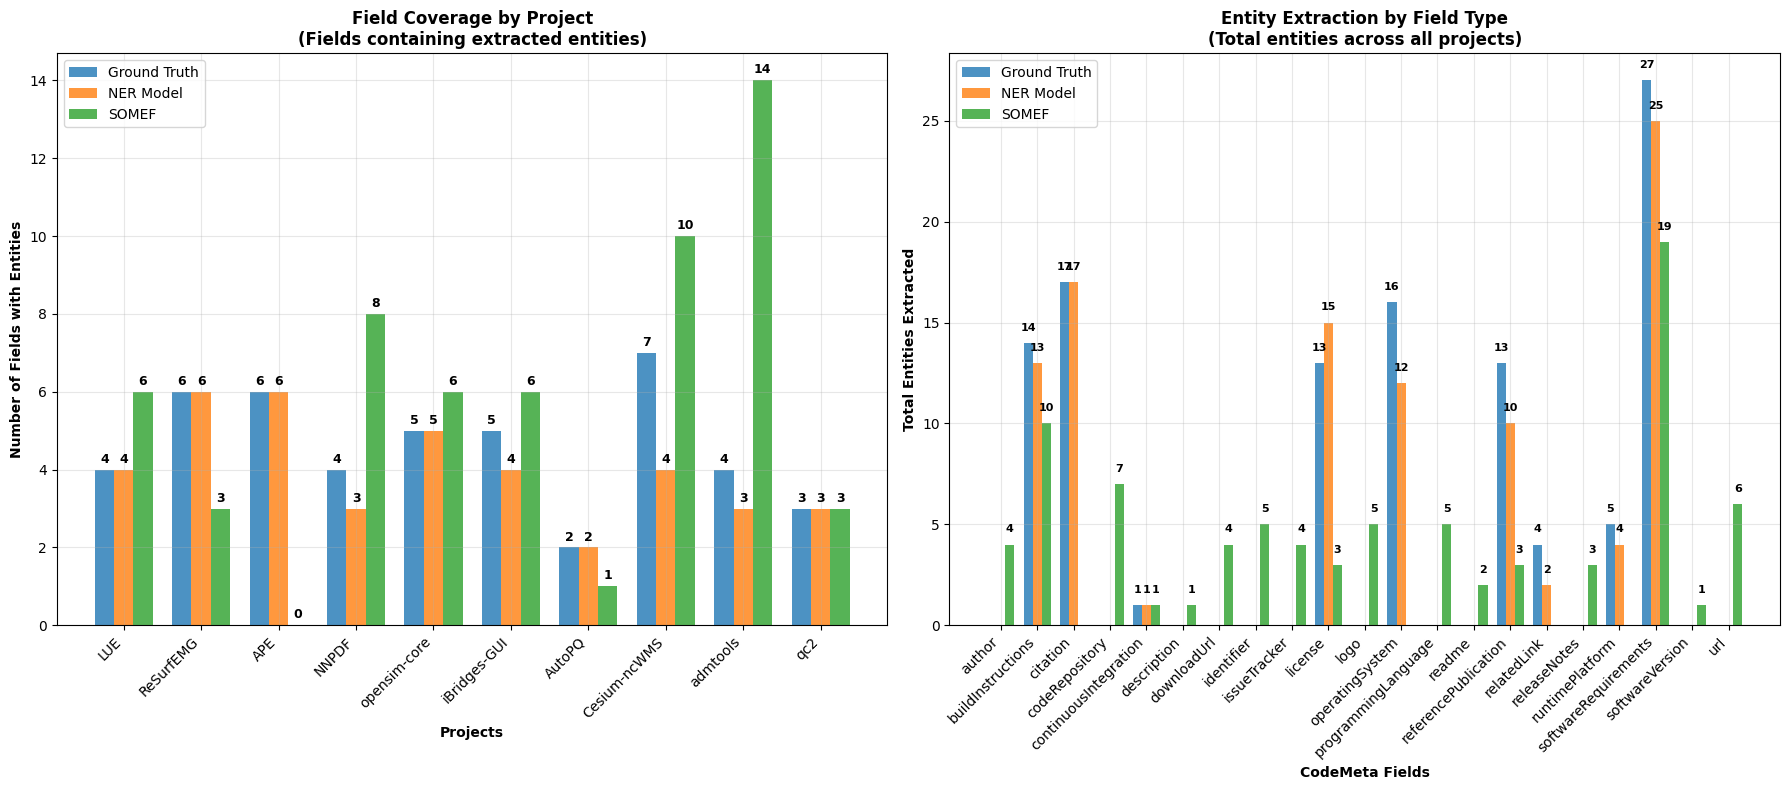

In [7]:
# Create comprehensive coverage visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Left: Field coverage by project with stacked bars showing entity counts
projects = evaluation_results['coverage_matrix']['projects']
gt_counts = evaluation_results['coverage_matrix']['gt_fields']
model_counts = evaluation_results['coverage_matrix']['model_fields']
somef_counts = evaluation_results['coverage_matrix']['somef_fields']

x = np.arange(len(projects))
width = 0.25

bars1 = ax1.bar(x - width, gt_counts, width, label='Ground Truth', alpha=0.8, color='#1f77b4')
bars2 = ax1.bar(x, model_counts, width, label='NER Model', alpha=0.8, color='#ff7f0e')
bars3 = ax1.bar(x + width, somef_counts, width, label='SOMEF', alpha=0.8, color='#2ca02c')

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                f'{int(height)}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax1.set_xlabel('Projects', fontweight='bold')
ax1.set_ylabel('Number of Fields with Entities', fontweight='bold')
ax1.set_title('Field Coverage by Project\n(Fields containing extracted entities)', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(projects, rotation=45, ha='right')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right: Entity count by field type
fields_with_entities = [field for field in evaluation_results['all_fields'] 
                       if any(field_entity_counts[field][method] > 0 for method in ['gt', 'model', 'somef'])]

gt_field_entities = [field_entity_counts[field]['gt'] for field in fields_with_entities]
model_field_entities = [field_entity_counts[field]['model'] for field in fields_with_entities]
somef_field_entities = [field_entity_counts[field]['somef'] for field in fields_with_entities]

x2 = np.arange(len(fields_with_entities))
width2 = 0.25

bars1 = ax2.bar(x2 - width2, gt_field_entities, width2, label='Ground Truth', alpha=0.8, color='#1f77b4')
bars2 = ax2.bar(x2, model_field_entities, width2, label='NER Model', alpha=0.8, color='#ff7f0e')
bars3 = ax2.bar(x2 + width2, somef_field_entities, width2, label='SOMEF', alpha=0.8, color='#2ca02c')

# Add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax2.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                    f'{int(height)}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax2.set_xlabel('CodeMeta Fields', fontweight='bold')
ax2.set_ylabel('Total Entities Extracted', fontweight='bold')
ax2.set_title('Entity Extraction by Field Type\n(Total entities across all projects)', fontsize=12, fontweight='bold')
ax2.set_xticks(x2)
ax2.set_xticklabels(fields_with_entities, rotation=45, ha='right')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(evaluator.output_dir / 'entity_coverage_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Performance Metrics with Ground Truth Baseline

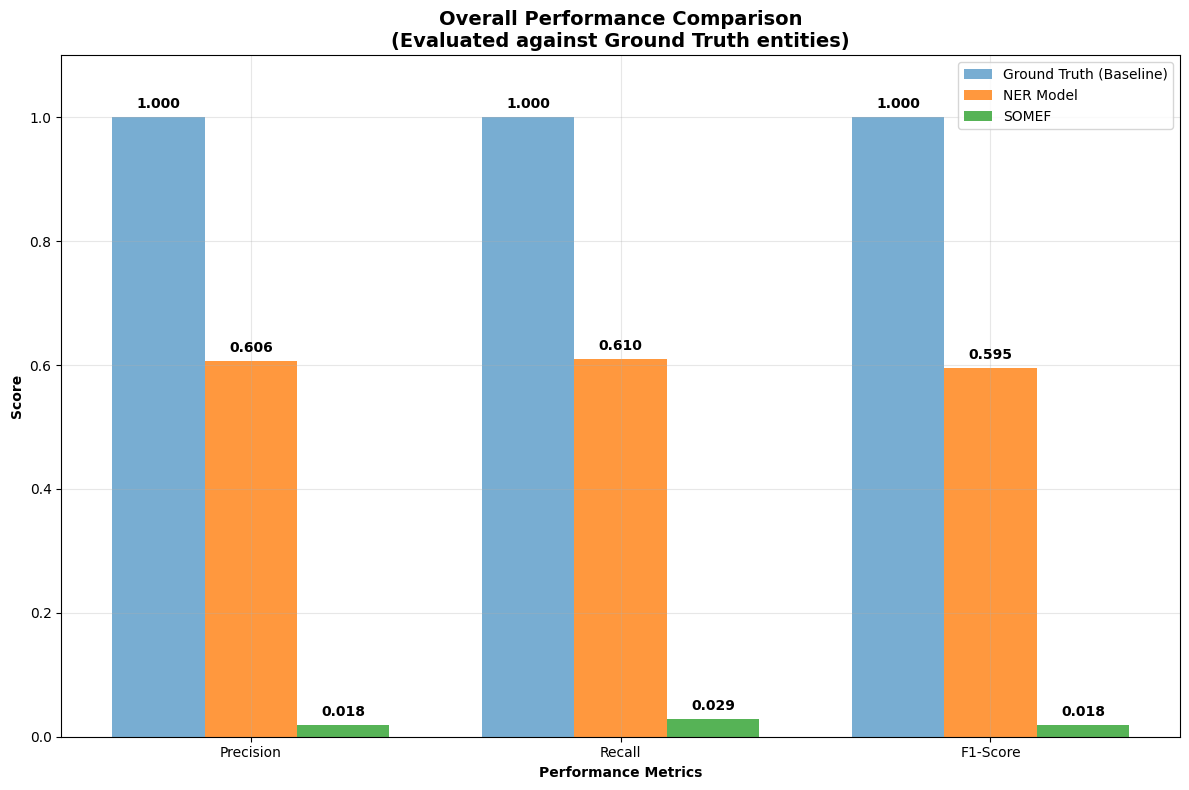


=== PERFORMANCE SUMMARY ===
NER Model  - Precision: 0.606, Recall: 0.610, F1: 0.595
SOMEF      - Precision: 0.018, Recall: 0.029, F1: 0.018


In [8]:
# Calculate overall performance metrics
model_precision = [metrics['model']['precision'] for metrics in evaluation_results['project_metrics'].values()]
model_recall = [metrics['model']['recall'] for metrics in evaluation_results['project_metrics'].values()]
model_f1 = [metrics['model']['f1'] for metrics in evaluation_results['project_metrics'].values()]

somef_precision = [metrics['somef']['precision'] for metrics in evaluation_results['project_metrics'].values()]
somef_recall = [metrics['somef']['recall'] for metrics in evaluation_results['project_metrics'].values()]
somef_f1 = [metrics['somef']['f1'] for metrics in evaluation_results['project_metrics'].values()]

# Performance comparison
fig, ax = plt.subplots(figsize=(12, 8))

metrics_names = ['Precision', 'Recall', 'F1-Score']
model_scores = [np.mean(model_precision), np.mean(model_recall), np.mean(model_f1)]
somef_scores = [np.mean(somef_precision), np.mean(somef_recall), np.mean(somef_f1)]
gt_baseline = [1.0, 1.0, 1.0]  # Perfect ground truth baseline

x = np.arange(len(metrics_names))
width = 0.25

bars1 = ax.bar(x - width, gt_baseline, width, label='Ground Truth (Baseline)', alpha=0.6, color='#1f77b4')
bars2 = ax.bar(x, model_scores, width, label='NER Model', alpha=0.8, color='#ff7f0e')
bars3 = ax.bar(x + width, somef_scores, width, label='SOMEF', alpha=0.8, color='#2ca02c')

# Add value labels
for bars, scores in [(bars1, gt_baseline), (bars2, model_scores), (bars3, somef_scores)]:
    for bar, score in zip(bars, scores):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{score:.3f}', ha='center', va='bottom', fontweight='bold')

ax.set_xlabel('Performance Metrics', fontweight='bold')
ax.set_ylabel('Score', fontweight='bold')
ax.set_title('Overall Performance Comparison\n(Evaluated against Ground Truth entities)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.legend()
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(evaluator.output_dir / 'performance_with_baseline.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n=== PERFORMANCE SUMMARY ===")
print(f"NER Model  - Precision: {np.mean(model_precision):.3f}, Recall: {np.mean(model_recall):.3f}, F1: {np.mean(model_f1):.3f}")
print(f"SOMEF      - Precision: {np.mean(somef_precision):.3f}, Recall: {np.mean(somef_recall):.3f}, F1: {np.mean(somef_f1):.3f}")

## 4. Field-Specific Performance Analysis

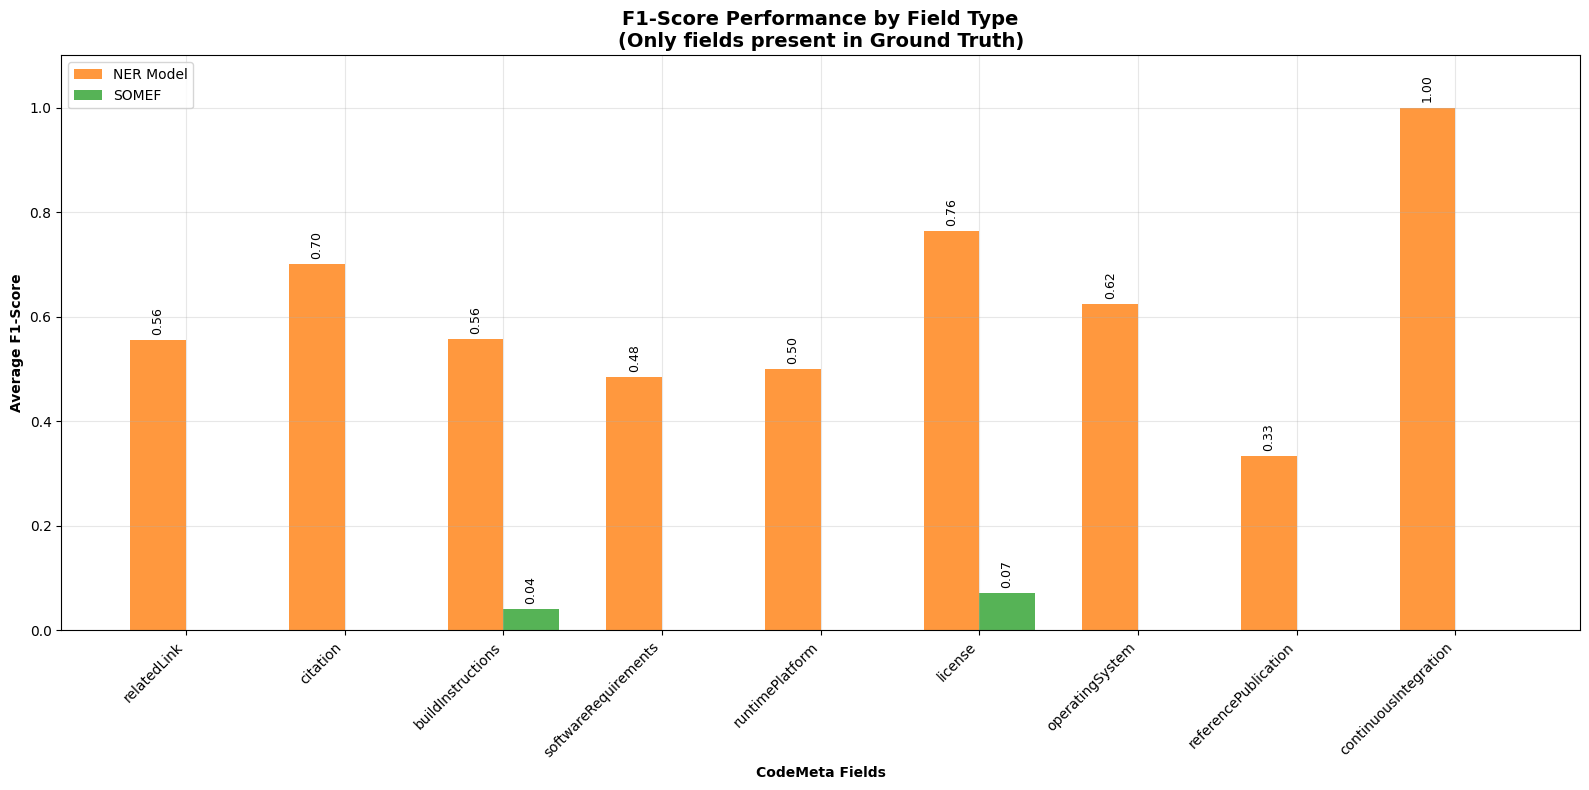


=== FIELD-SPECIFIC STRENGTHS ===

NER Model performs better on:
  continuousIntegration: Model=1.000, SOMEF=0.000 (Δ=1.000)
  license: Model=0.764, SOMEF=0.071 (Δ=0.692)
  citation: Model=0.700, SOMEF=0.000 (Δ=0.700)
  operatingSystem: Model=0.624, SOMEF=0.000 (Δ=0.624)
  buildInstructions: Model=0.557, SOMEF=0.041 (Δ=0.516)
  relatedLink: Model=0.556, SOMEF=0.000 (Δ=0.556)
  runtimePlatform: Model=0.500, SOMEF=0.000 (Δ=0.500)
  softwareRequirements: Model=0.484, SOMEF=0.000 (Δ=0.484)
  referencePublication: Model=0.333, SOMEF=0.000 (Δ=0.333)

SOMEF performs better on:


In [9]:
# Field-specific F1 scores
fields_with_metrics = [field for field in evaluation_results['field_metrics'].keys() 
                      if evaluation_results['field_metrics'][field]['model'] or evaluation_results['field_metrics'][field]['somef']]

if fields_with_metrics:
    model_field_f1 = [np.mean(evaluation_results['field_metrics'][field]['model']) 
                      if evaluation_results['field_metrics'][field]['model'] else 0 
                      for field in fields_with_metrics]
    somef_field_f1 = [np.mean(evaluation_results['field_metrics'][field]['somef']) 
                     if evaluation_results['field_metrics'][field]['somef'] else 0 
                     for field in fields_with_metrics]
    
    fig, ax = plt.subplots(figsize=(16, 8))
    
    x = np.arange(len(fields_with_metrics))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, model_field_f1, width, label='NER Model', alpha=0.8, color='#ff7f0e')
    bars2 = ax.bar(x + width/2, somef_field_f1, width, label='SOMEF', alpha=0.8, color='#2ca02c')
    
    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                        f'{height:.2f}', ha='center', va='bottom', fontsize=9, rotation=90)
    
    ax.set_xlabel('CodeMeta Fields', fontweight='bold')
    ax.set_ylabel('Average F1-Score', fontweight='bold')
    ax.set_title('F1-Score Performance by Field Type\n(Only fields present in Ground Truth)', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(fields_with_metrics, rotation=45, ha='right')
    ax.legend()
    ax.set_ylim(0, 1.1)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(evaluator.output_dir / 'field_specific_performance.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Identify method strengths
    model_strengths = []
    somef_strengths = []
    
    for i, field in enumerate(fields_with_metrics):
        if model_field_f1[i] > somef_field_f1[i]:
            model_strengths.append((field, model_field_f1[i], somef_field_f1[i]))
        elif somef_field_f1[i] > model_field_f1[i]:
            somef_strengths.append((field, somef_field_f1[i], model_field_f1[i]))
    
    print("\n=== FIELD-SPECIFIC STRENGTHS ===")
    print("\nNER Model performs better on:")
    for field, model_score, somef_score in sorted(model_strengths, key=lambda x: x[1], reverse=True):
        print(f"  {field}: Model={model_score:.3f}, SOMEF={somef_score:.3f} (Δ={model_score-somef_score:.3f})")
    
    print("\nSOMEF performs better on:")
    for field, somef_score, model_score in sorted(somef_strengths, key=lambda x: x[1], reverse=True):
        print(f"  {field}: SOMEF={somef_score:.3f}, Model={model_score:.3f} (Δ={somef_score-model_score:.3f})")

## 5. Project-Level Performance Analysis

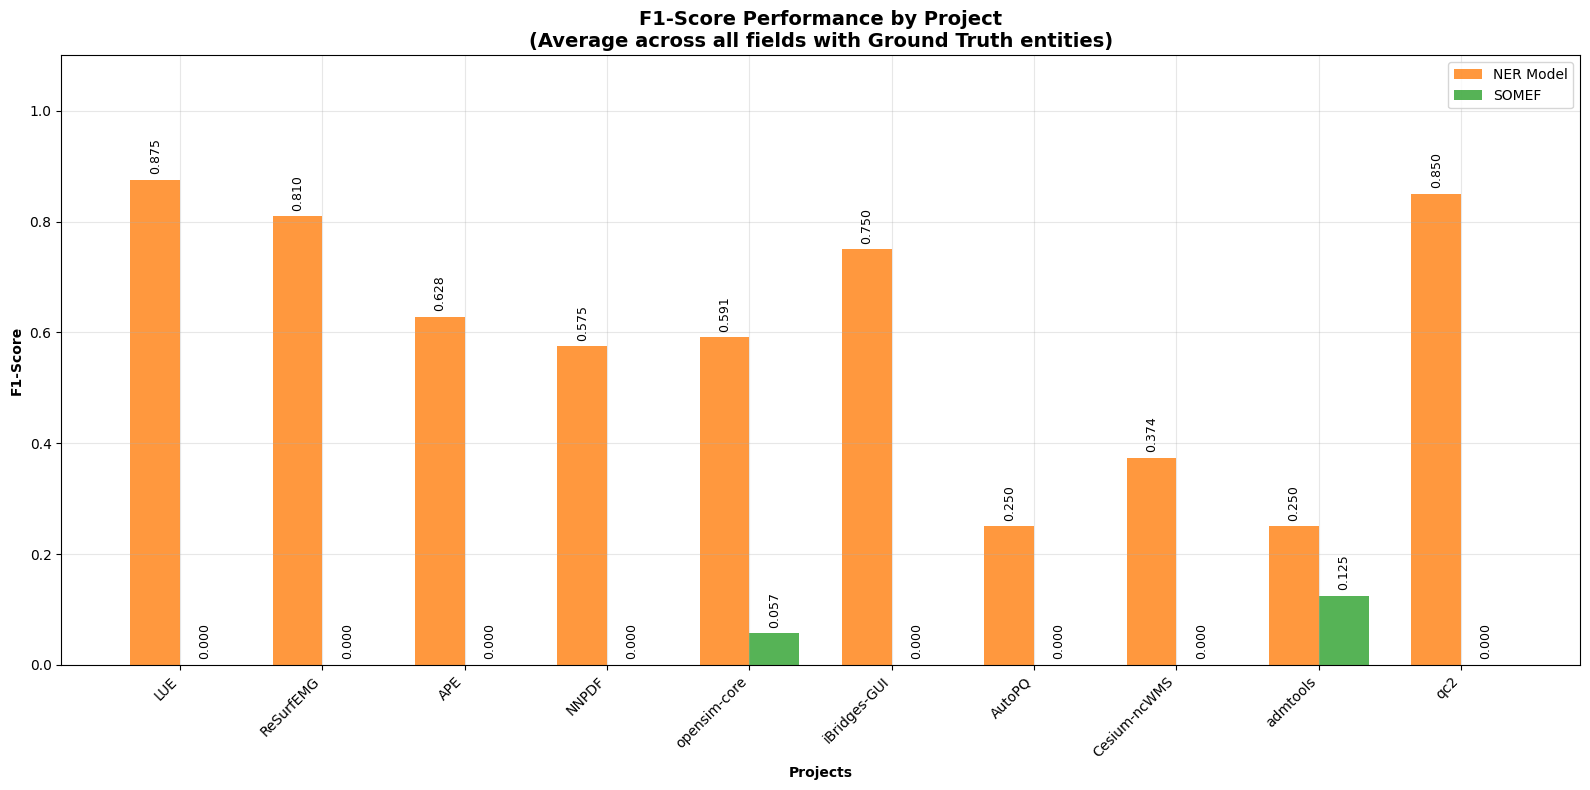


=== PROJECT PERFORMANCE SUMMARY ===
LUE             - Model: 0.875, SOMEF: 0.000 → Model
ReSurfEMG       - Model: 0.810, SOMEF: 0.000 → Model
APE             - Model: 0.628, SOMEF: 0.000 → Model
NNPDF           - Model: 0.575, SOMEF: 0.000 → Model
opensim-core    - Model: 0.591, SOMEF: 0.057 → Model
iBridges-GUI    - Model: 0.750, SOMEF: 0.000 → Model
AutoPQ          - Model: 0.250, SOMEF: 0.000 → Model
Cesium-ncWMS    - Model: 0.374, SOMEF: 0.000 → Model
admtools        - Model: 0.250, SOMEF: 0.125 → Model
qc2             - Model: 0.850, SOMEF: 0.000 → Model


In [10]:
# Project-wise performance
projects = evaluation_results['projects']
project_model_f1 = [evaluation_results['project_metrics'][p]['model']['f1'] for p in projects]
project_somef_f1 = [evaluation_results['project_metrics'][p]['somef']['f1'] for p in projects]

fig, ax = plt.subplots(figsize=(16, 8))

x = np.arange(len(projects))
width = 0.35

bars1 = ax.bar(x - width/2, project_model_f1, width, label='NER Model', alpha=0.8, color='#ff7f0e')
bars2 = ax.bar(x + width/2, project_somef_f1, width, label='SOMEF', alpha=0.8, color='#2ca02c')

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9, rotation=90)

ax.set_xlabel('Projects', fontweight='bold')
ax.set_ylabel('F1-Score', fontweight='bold')
ax.set_title('F1-Score Performance by Project\n(Average across all fields with Ground Truth entities)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(projects, rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(evaluator.output_dir / 'project_performance.png', dpi=300, bbox_inches='tight')
plt.show()

# Project performance summary
print("\n=== PROJECT PERFORMANCE SUMMARY ===")
for i, project in enumerate(projects):
    model_score = project_model_f1[i]
    somef_score = project_somef_f1[i]
    winner = "Model" if model_score > somef_score else "SOMEF" if somef_score > model_score else "Tie"
    print(f"{project:15} - Model: {model_score:.3f}, SOMEF: {somef_score:.3f} → {winner}")

## 6. Detailed Entity Extraction Results

In [ ]:
# Show detailed entity extraction for a sample project
sample_project = evaluation_results['projects'][0]
sample_entities = evaluation_results['entity_extraction'][sample_project]

print(f"\n=== DETAILED ENTITY EXTRACTION: {sample_project} ===")
print("\nField-by-field entity extraction comparison:")

for field in evaluation_results['all_fields']:
    gt_entities = sample_entities['gt'].get(field, [])
    model_entities = sample_entities['model'].get(field, [])
    somef_entities = sample_entities['somef'].get(field, [])
    
    if gt_entities or model_entities or somef_entities:
        print(f"\n{field.upper()}:")
        print(f"  Ground Truth ({len(gt_entities)}): {gt_entities}")
        print(f"  NER Model ({len(model_entities)}):    {model_entities}")
        print(f"  SOMEF ({len(somef_entities)}):        {somef_entities}")
        
        # Calculate overlap
        if gt_entities:
            gt_set = set(gt_entities)
            model_set = set(model_entities)
            somef_set = set(somef_entities)
            
            model_overlap = len(gt_set.intersection(model_set)) / len(gt_set)
            somef_overlap = len(gt_set.intersection(somef_set)) / len(gt_set)
            
            print(f"  → Model overlap with GT: {model_overlap:.2%}")
            print(f"  → SOMEF overlap with GT: {somef_overlap:.2%}")

# Save detailed results
with open(evaluator.output_dir / 'detailed_entity_extraction.json', 'w') as f:
    json.dump(evaluation_results['entity_extraction'], f, indent=2)

# Save summary metrics
summary_df = pd.DataFrame([
    {
        'Project': project,
        'Model_Precision': f"{metrics['model']['precision']:.3f}",
        'Model_Recall': f"{metrics['model']['recall']:.3f}",
        'Model_F1': f"{metrics['model']['f1']:.3f}",
        'SOMEF_Precision': f"{metrics['somef']['precision']:.3f}",
        'SOMEF_Recall': f"{metrics['somef']['recall']:.3f}",
        'SOMEF_F1': f"{metrics['somef']['f1']:.3f}",
        'GT_Fields': metrics['coverage']['gt'],
        'Model_Fields': metrics['coverage']['model'],
        'SOMEF_Fields': metrics['coverage']['somef']
    }
    for project, metrics in evaluation_results['project_metrics'].items()
])

summary_df.to_csv(evaluator.output_dir / 'evaluation_results.csv', index=False)

print(f"\n\nDetailed results saved to {evaluator.output_dir}/")
print("Files generated:")
print("- evaluation_results.csv")
print("- detailed_entity_extraction.json")
print("- entity_coverage_analysis.png")
print("- performance_with_baseline.png")
print("- field_specific_performance.png")
print("- project_performance.png")


=== DETAILED ENTITY EXTRACTION: LUE ===

Field-by-field entity extraction comparison:

BUILDINSTRUCTIONS:
  Ground Truth (1): ['https://lue.computationalgeography.org/doc']
  NER Model (3):    ['https://lue.computationalgeography.org', 'https://lue.computationalgeography.org/doc', 'https://lue.computationalgeography.org/publication']
  SOMEF (2):        ['https://raw.githubusercontent.com/computationalgeography/lue/master/README.md', 'https://github.com/computationalgeography/lue/wiki']
  → Model overlap with GT: 100.00%
  → SOMEF overlap with GT: 0.00%

CITATION:
  Ground Truth (1): ['https://doi.org/10.5281/zenodo.5535685']
  NER Model (1):    ['https://doi.org/10.5281/zenodo.5535685']
  SOMEF (0):        []
  → Model overlap with GT: 100.00%
  → SOMEF overlap with GT: 0.00%

CODEREPOSITORY:
  Ground Truth (0): []
  NER Model (0):    []
  SOMEF (1):        ['https://github.com/computationalgeography/lue']

DESCRIPTION:
  Ground Truth (0): []
  NER Model (0):    []
  SOMEF (1):      